In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('Mall_Customers_P.csv')

In [3]:
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
245,246,Male,30,297,69
246,247,Female,56,311,14
247,248,Male,29,313,90
248,249,Female,19,316,32


In [4]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
data.shape


(250, 5)

In [6]:
data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
data.isnull().any().any

<bound method Series.any of CustomerID                False
Gender                    False
Age                       False
Annual Income (k$)        False
Spending Score (1-100)    False
dtype: bool>

In [10]:
x=data.loc[:,['Annual Income (k$)',
               'Spending Score (1-100)']].values

In [11]:
print(x.shape)

(250, 2)


In [12]:
from sklearn.neighbors import NearestNeighbors
neighb = NearestNeighbors(n_neighbors=2)
nbrs=neighb.fit(x)
distance , indices=nbrs.kneighbors(x)

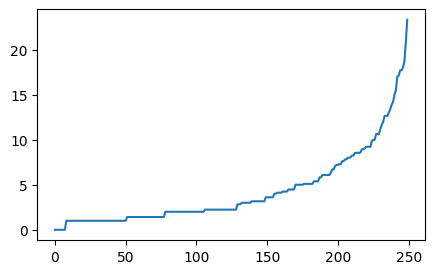

In [15]:
distance = np.sort(distance,axis=0)
distance = distance[:,1]
plt.rcParams['figure.figsize']=(5,3)
plt.plot(distance)
plt.show()

In [17]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps =8,min_samples = 4).fit(x)
labels = dbscan.labels_

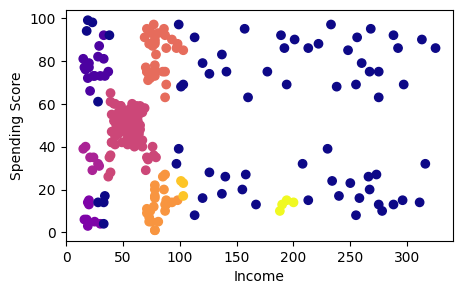

In [18]:
plt.scatter(x[:,0],x[:,1],c=labels  ,cmap="plasma")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()